# Module 12 — Multi-Armed Bandits

Part of the **A/B Testing Playbook** learning program — the second and final module of the extension added 2026-09-18 after an honest self-critique. Full program context: see `CURRICULUM.md`.

## From the curriculum

> **Concepts**
> - The explore-exploit tradeoff
> - Epsilon-greedy, the simplest bandit algorithm
> - Thompson Sampling — using Module 11's Bayesian posterior to decide live traffic allocation
> - When a bandit is the right call vs. a fixed-split A/B test, and the causal-inference cost of choosing one
>
> **Why it matters**
> A real, commonly-asked alternative paradigm to fixed A/B testing, especially relevant for ranking/recommendation-heavy B2C contexts — and a natural showcase of Module 11's machinery actually being used for something.
>
> **Worked example**
> Three variants with different true conversion rates: a fixed 33/33/33 split vs. a Thompson Sampling bandit, run over the same total traffic. Compare total conversions captured (the bandit should win) against how confidently each design lets you state the true ranking at the end (the fixed split should win) — the actual real tradeoff, not a one-sided pitch for bandits.
>
> **Resources**
> - [Multi-arm bandit testing: when to use it (and when not to)](https://www.growthbook.io/blog/guide-to-multi-arm-bandits-what-is-it-and-why-you-probably-shouldnt-use-it) — Graham McNicoll, GrowthBook Blog (verified, ~10 min)
> - [Thompson Sampling](https://towardsdatascience.com/thompson-sampling-fc28817eacb8/) — Steve Roberts, Towards Data Science (verified, ~8 min)
>
> **Exercise type:** computational — implement epsilon-greedy and Thompson Sampling from scratch, compare cumulative reward vs. a fixed split.
>
> **Interview angle:** "when would you use a bandit instead of an A/B test."

## Lesson

### The explore-exploit tradeoff

Every variant test faces the same tension: you want to learn which variant is truly best (**explore** — send traffic to all of them so you can compare), but you also want to send as much traffic as possible to whichever variant is actually best (**exploit** — capture the reward now, not later). A fixed 33/33/33 A/B test resolves this by doing the two in sequence: explore fully (equal traffic, no shortcuts) for the whole test, then exploit fully (100% of traffic to the winner) only once the test is over. A bandit resolves it differently — it explores and exploits *at the same time*, continuously shifting more traffic toward whichever variant looks best *while the test is still running*, never fully committing but never fully holding back either.

Each variant being tested is called an **arm** — bandit terminology borrowed from a casino slot machine (a "one-armed bandit"): each lever you could pull is an arm, and you don't know in advance which one pays out best.

### Epsilon-greedy: the simplest bandit algorithm

Epsilon-greedy's rule, every single round: with probability **epsilon**, pick a uniformly random arm (explore); the rest of the time, pick whichever arm currently has the highest observed successes/pulls ratio (exploit).

Concretely, with 3 arms and epsilon = 0.10: on any given round there's a 10% chance the algorithm ignores everything it's learned so far and picks uniformly among the 3 arms (a 10%/3 = 3.33% chance for each one individually); the other 90% of the time, it picks whichever single arm currently looks best. Once one arm is clearly ahead, exploitation sends the large majority of traffic there — but exploration never fully stops: that fixed 10% keeps getting spent on trying other arms, forever, no matter how confident the current estimates have become.

### Thompson Sampling

Thompson Sampling replaces epsilon-greedy's coin flip with Module 11's exact machinery: each arm gets its own Beta posterior (Beta(1, 1) prior, updated with `alpha += 1` per success and `beta += 1` per failure — precisely the update rule from Module 11). On every round, draw one random sample from each arm's current posterior, and send that round's traffic to whichever arm's **sample** happened to come out highest — not whichever arm's posterior mean is highest, which would be a different, more short-sighted algorithm.

Because the sample is random, an arm with a wide, uncertain posterior occasionally samples very high purely by chance, giving it a fair shot at being explored. But as more data accumulates, each posterior narrows — Module 11's own formula, variance = alpha × beta / ((alpha+beta)² × (alpha+beta+1)), has a denominator that grows roughly as the *cube* of (alpha+beta) — so a losing arm's samples become less and less likely to beat the winning arm's samples, purely as a mechanical consequence of the posterior narrowing, not a separate rule bolted on.

### When a bandit is the right call — the causal-inference cost

Both algorithms above converge toward sending most traffic to the best arm — great for total reward captured during the test itself. But that convergence has a real cost: arms judged "not the best" stop receiving much traffic early, often on the basis of relatively little data. By the end of the test, every arm besides the winner may have a small, and wildly unequal, sample size — which directly weakens how confidently you can say anything about how *they* compare to each other. A fixed 33/33/33 split never has this problem: every arm gets equal traffic for the test's full duration, by design, so every pairwise comparison ends with comparable statistical power. Part 3 below shows this concretely, not just asserts it.

### Part 1 — Epsilon-greedy, implemented from scratch

Three variants, three different true conversion rates (known to us for this simulation, never revealed to the algorithm): Arm A = 5.0%, Arm B = 5.5%, Arm C = 6.5%. 60,000 total rounds — the same order of magnitude as every other module's worked example.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

GOOD = "#0ca30c"       # Arm C -- best true rate
WARNING = "#fab219"    # Arm B -- middle true rate
CRITICAL = "#d03b3b"   # Arm A -- worst true rate
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
ARM_COLOR = {"A": CRITICAL, "B": WARNING, "C": GOOD}

p_true = {"A": 0.050, "B": 0.055, "C": 0.065}  # known to us only, not to the algorithms
arms = list(p_true.keys())
N_total = 60_000
epsilon = 0.10

def run_epsilon_greedy(n_total, epsilon, seed):
    rng = np.random.default_rng(seed)
    counts = {a: 0 for a in arms}
    successes = {a: 0 for a in arms}
    choice_log = []
    for t in range(n_total):
        if t < len(arms):
            chosen = arms[t]  # try each arm once first, so "highest observed rate" is defined
        elif rng.random() < epsilon:
            chosen = arms[rng.integers(len(arms))]
        else:
            rates = {a: successes[a] / counts[a] if counts[a] > 0 else 0 for a in arms}
            chosen = max(rates, key=rates.get)
        outcome = rng.random() < p_true[chosen]
        counts[chosen] += 1
        successes[chosen] += outcome
        choice_log.append(chosen)
    return counts, successes, choice_log

counts_eg, succ_eg, log_eg = run_epsilon_greedy(N_total, epsilon, seed=31)

print(f"Epsilon-greedy (epsilon={epsilon}), {N_total:,} total rounds:")
for a in arms:
    rate = succ_eg[a] / counts_eg[a]
    print(f"  Arm {a} (true rate {p_true[a]:.1%}): {counts_eg[a]:,} pulls, {succ_eg[a]} successes, observed rate {rate:.3%}")
total_eg = sum(succ_eg.values())
print(f"Total conversions captured: {total_eg}")

Epsilon-greedy (epsilon=0.1), 60,000 total rounds:
  Arm A (true rate 5.0%): 2,283 pulls, 121 successes, observed rate 5.300%
  Arm B (true rate 5.5%): 5,515 pulls, 297 successes, observed rate 5.385%
  Arm C (true rate 6.5%): 52,202 pulls, 3384 successes, observed rate 6.483%
Total conversions captured: 3802


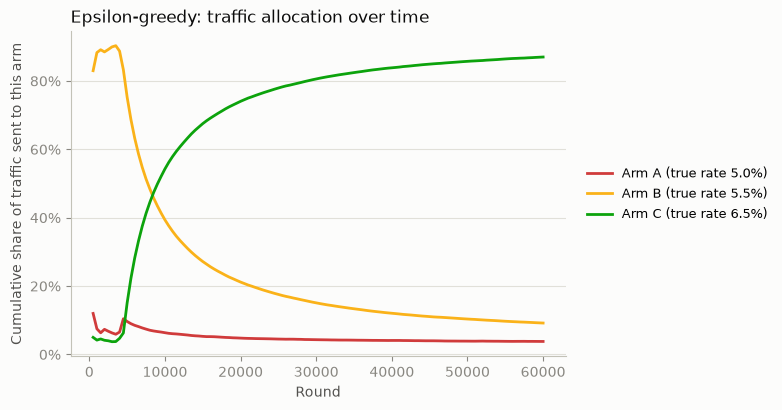

In [2]:
window = 500
rounds = np.arange(window, N_total + 1, window)
cum_frac = {a: [] for a in arms}
running = {a: 0 for a in arms}
for i, choice in enumerate(log_eg, start=1):
    running[choice] += 1
    if i % window == 0:
        for a in arms:
            cum_frac[a].append(running[a] / i)

fig, ax = plt.subplots(figsize=(7.5, 4.4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for a in arms:
    ax.plot(rounds, cum_frac[a], color=ARM_COLOR[a], linewidth=2, label=f"Arm {a} (true rate {p_true[a]:.1%})")
ax.set_xlabel("Round", color=INK_SECONDARY)
ax.set_ylabel("Cumulative share of traffic sent to this arm", color=INK_SECONDARY)
ax.set_title("Epsilon-greedy: traffic allocation over time", color=INK, fontsize=12, loc="left")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)

fig.subplots_adjust(left=0.10, right=0.76, top=0.88, bottom=0.14)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.show()

In [3]:
inferior_arms = len(arms) - 1  # A and B -- everyone except the true best, Arm C
floor_per_inferior_arm = epsilon / len(arms)
floor_total_inferior = epsilon * inferior_arms / len(arms)
last_window = 10_000
last_inferior_fraction = sum(1 for a in log_eg[-last_window:] if a != "C") / last_window

print(f"Theoretical floor per inferior arm = epsilon / num_arms = {epsilon} / {len(arms)} = {floor_per_inferior_arm:.4f} = {floor_per_inferior_arm:.2%}")
print(f"Theoretical floor, A and B combined = epsilon x {inferior_arms}/{len(arms)} = {epsilon} x {inferior_arms}/{len(arms)} = {floor_total_inferior:.4f} = {floor_total_inferior:.2%}")
print(f"Observed fraction sent to A or B in the LAST {last_window:,} rounds = {last_inferior_fraction:.2%}")

Theoretical floor per inferior arm = epsilon / num_arms = 0.1 / 3 = 0.0333 = 3.33%
Theoretical floor, A and B combined = epsilon x 2/3 = 0.1 x 2/3 = 0.0667 = 6.67%
Observed fraction sent to A or B in the LAST 10,000 rounds = 6.67%


**What this shows:** the observed last-window fraction (6.67%) matches the theoretical floor (6.67%) almost exactly — and that's not a coincidence, it's baked directly into the algorithm's own definition. The `rng.random() < epsilon` branch runs with probability epsilon on *every single round*, completely independent of how many rounds have already run or how confident the current rate estimates have become. No matter how much more data piles up confirming Arm C is best, epsilon-greedy will keep sending exactly this floor's worth of traffic to the inferior arms — forever.

### Part 2 — Thompson Sampling, implemented from scratch

Same three arms, same 60,000 rounds — swapping epsilon-greedy's coin flip for a draw from each arm's Beta posterior.

In [4]:
def run_thompson(n_total, seed):
    rng = np.random.default_rng(seed)
    alpha = {a: 1 for a in arms}  # Beta(1, 1) prior -- same flat prior as Module 11
    beta = {a: 1 for a in arms}
    choice_log = []
    for t in range(n_total):
        samples = {a: rng.beta(alpha[a], beta[a]) for a in arms}
        chosen = max(samples, key=samples.get)
        outcome = rng.random() < p_true[chosen]
        if outcome:
            alpha[chosen] += 1
        else:
            beta[chosen] += 1
        choice_log.append(chosen)
    return alpha, beta, choice_log

alpha_ts, beta_ts, log_ts = run_thompson(N_total, seed=32)

print(f"Thompson Sampling, {N_total:,} total rounds:")
for a in arms:
    n = alpha_ts[a] + beta_ts[a] - 2
    x = alpha_ts[a] - 1
    rate = x / n
    print(f"  Arm {a} (true rate {p_true[a]:.1%}): {n:,} pulls, {x} successes, observed rate {rate:.3%}, posterior Beta({alpha_ts[a]}, {beta_ts[a]})")
total_ts = sum(alpha_ts[a] - 1 for a in arms)
print(f"Total conversions captured: {total_ts}")

Thompson Sampling, 60,000 total rounds:
  Arm A (true rate 5.0%): 2,916 pulls, 148 successes, observed rate 5.075%, posterior Beta(149, 2769)
  Arm B (true rate 5.5%): 4,895 pulls, 280 successes, observed rate 5.720%, posterior Beta(281, 4616)
  Arm C (true rate 6.5%): 52,189 pulls, 3330 successes, observed rate 6.381%, posterior Beta(3331, 48860)
Total conversions captured: 3758


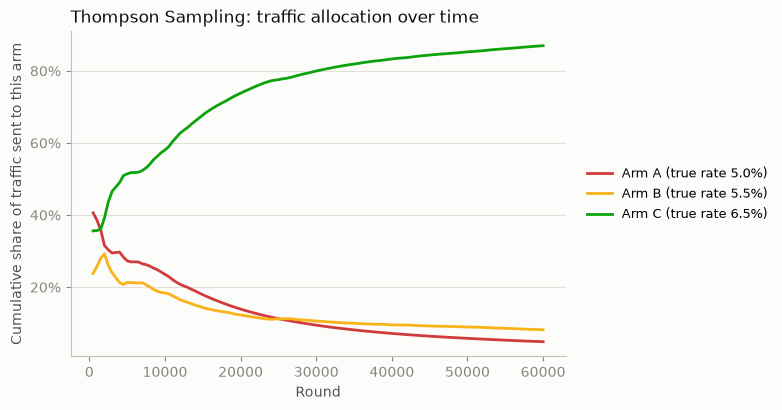

In [5]:
cum_frac_ts = {a: [] for a in arms}
running_ts = {a: 0 for a in arms}
for i, choice in enumerate(log_ts, start=1):
    running_ts[choice] += 1
    if i % window == 0:
        for a in arms:
            cum_frac_ts[a].append(running_ts[a] / i)

fig, ax = plt.subplots(figsize=(7.5, 4.4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for a in arms:
    ax.plot(rounds, cum_frac_ts[a], color=ARM_COLOR[a], linewidth=2, label=f"Arm {a} (true rate {p_true[a]:.1%})")
ax.set_xlabel("Round", color=INK_SECONDARY)
ax.set_ylabel("Cumulative share of traffic sent to this arm", color=INK_SECONDARY)
ax.set_title("Thompson Sampling: traffic allocation over time", color=INK, fontsize=12, loc="left")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)

fig.subplots_adjust(left=0.10, right=0.76, top=0.88, bottom=0.14)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.show()

**What this shows:** both algorithms make the same big first move — heavy exploration for roughly the first 10,000-20,000 rounds while there isn't yet enough data to be confident which arm is best, then a sharp shift toward Arm C once it visibly pulls ahead. The two curves' *endings* land in a similar range here (both around 5-9% of traffic still going to the inferior arms by round 60,000) — this particular run isn't long enough to make the structural difference visually obvious.

That structural difference is still real, and it doesn't need a longer chart to prove it: it follows directly from each algorithm's own definition, the same way Part 1's 6.67% floor did. Epsilon-greedy's exploration rate is a fixed constant, unrelated to confidence. Thompson Sampling's exploration rate is driven entirely by how *wide* each arm's posterior still is — and posterior width shrinks as pulls accumulate (Module 11's variance formula, cited above). So given enough rounds, Thompson's exploration of a clearly-losing arm keeps shrinking toward zero, while epsilon-greedy's never will — provable from the algorithms as written, even where a moderate-length run like this one doesn't make it visually dramatic.

### Part 3 — The real comparison: fixed split vs. Thompson Sampling

The curriculum's actual worked example: the same 60,000 rounds, split the traditional way — 20,000 to each arm, no adapting.

In [6]:
def run_fixed(n_total, seed):
    rng = np.random.default_rng(seed)
    n_each = n_total // len(arms)
    results = {}
    for a in arms:
        x = rng.binomial(n_each, p_true[a])
        results[a] = (n_each, x)
    return results

fixed = run_fixed(N_total, seed=33)

print(f"Fixed 33/33/33 split, {N_total:,} total rounds:")
for a in arms:
    n, x = fixed[a]
    rate = x / n
    print(f"  Arm {a} (true rate {p_true[a]:.1%}): {n:,} pulls, {x} successes, observed rate {rate:.3%}")
total_fixed = sum(fixed[a][1] for a in arms)
print(f"Total conversions captured: {total_fixed}")

Fixed 33/33/33 split, 60,000 total rounds:
  Arm A (true rate 5.0%): 20,000 pulls, 1003 successes, observed rate 5.015%
  Arm B (true rate 5.5%): 20,000 pulls, 1143 successes, observed rate 5.715%
  Arm C (true rate 6.5%): 20,000 pulls, 1332 successes, observed rate 6.660%
Total conversions captured: 3478


In [7]:
best_possible = N_total * p_true["C"]  # if we'd known Arm C was best from round 1 and sent it all traffic
regret_fixed = best_possible - total_fixed
regret_ts = best_possible - total_ts

print(f"Best possible (100% of traffic to Arm C from round 1) = {N_total:,} x {p_true['C']:.1%} = {best_possible:.0f} conversions")
print(f"Fixed split total:      {total_fixed} conversions -- {regret_fixed:.0f} short of best possible ('regret')")
print(f"Thompson Sampling total: {total_ts} conversions -- {regret_ts:.0f} short of best possible")
print(f"Thompson Sampling captured {total_ts - total_fixed} more conversions than the fixed split over the same {N_total:,} rounds ({(total_ts - total_fixed) / total_fixed:.1%} more)")

Best possible (100% of traffic to Arm C from round 1) = 60,000 x 6.5% = 3900 conversions
Fixed split total:      3478 conversions -- 422 short of best possible ('regret')
Thompson Sampling total: 3758 conversions -- 142 short of best possible
Thompson Sampling captured 280 more conversions than the fixed split over the same 60,000 rounds (8.1% more)


In [8]:
def z_test(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2
    p_pool = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p2 - p1) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value

pairs = [("A", "B"), ("B", "C"), ("A", "C")]

print("Fixed split -- every pairwise comparison, same n=20,000 per arm:")
for a1, a2 in pairs:
    n1, x1 = fixed[a1]
    n2, x2 = fixed[a2]
    z, p = z_test(x1, n1, x2, n2)
    verdict = "significant (p<0.05)" if p < 0.05 else "NOT significant"
    print(f"  Arm {a2} vs. Arm {a1}: n={n1:,} each, z={z:.3f}, p={p:.4f} -> {verdict}")

print()
print("Thompson Sampling -- same pairwise comparisons, wildly unequal n:")
ts_n = {a: alpha_ts[a] + beta_ts[a] - 2 for a in arms}
ts_x = {a: alpha_ts[a] - 1 for a in arms}
for a1, a2 in pairs:
    z, p = z_test(ts_x[a1], ts_n[a1], ts_x[a2], ts_n[a2])
    verdict = "significant (p<0.05)" if p < 0.05 else "NOT significant"
    print(f"  Arm {a2} vs. Arm {a1}: n={ts_n[a1]:,} vs. {ts_n[a2]:,}, z={z:.3f}, p={p:.4f} -> {verdict}")

Fixed split -- every pairwise comparison, same n=20,000 per arm:
  Arm B vs. Arm A: n=20,000 each, z=3.107, p=0.0019 -> significant (p<0.05)
  Arm C vs. Arm B: n=20,000 each, z=3.922, p=0.0001 -> significant (p<0.05)
  Arm C vs. Arm A: n=20,000 each, z=7.016, p=0.0000 -> significant (p<0.05)

Thompson Sampling -- same pairwise comparisons, wildly unequal n:
  Arm B vs. Arm A: n=2,916 vs. 4,895, z=1.211, p=0.2259 -> NOT significant
  Arm C vs. Arm B: n=4,895 vs. 52,189, z=1.815, p=0.0694 -> NOT significant
  Arm C vs. Arm A: n=2,916 vs. 52,189, z=2.821, p=0.0048 -> significant (p<0.05)


**What this shows:** the fixed split's equal n=20,000 per arm gives every pairwise comparison real statistical power — all three come back significant, so you can confidently state the *full* ranking (A < B < C) once the test ends. Thompson Sampling only manages this for the most extreme comparison (A vs. C, the biggest true gap) — A vs. B and B vs. C both come back not significant, because those two arms only received 2,916 and 4,895 pulls respectively (versus 20,000 each in the fixed split), precisely because Thompson correctly deprioritized them once C pulled ahead.

You captured more reward during the test (+280 conversions, derived above) — but you end the test *less* able to say anything confident about how A and B actually compare to each other. That's the exact tradeoff the curriculum named, now derived on real simulated numbers rather than asserted.

## Bandit or fixed split? The actual decision

**Run a bandit when the test itself is the deployment** — a time-boxed campaign where the only thing that matters is total reward captured while it's live (a 2-week holiday banner, a limited promo you'll retire entirely the moment it ends, regardless of which variant "won"). Thompson Sampling captured 280 more conversions than the fixed split over the same 60,000 rounds here — a real, derived number, not a promise — precisely because it acts on information the fixed split ignores until the test is already over.

**Run a fixed split when you need a defensible, permanent decision** — something you'll be asked to justify afterward with "here's the evidence for A vs. B, and here's the evidence for B vs. C" (a checkout flow going forward, a pricing page that stays live for a year). The fixed split was the only one of the two designs that ended this test able to confidently state all three pairwise comparisons. The bandit's own success — correctly recognizing Arm C was best, fast — is exactly what starved Arms A and B of the traffic needed to confidently rank them against each other.

Neither design is strictly better. They're optimized for two different questions: "what should I do with THIS traffic, right now" (bandit) vs. "what do I get to confidently claim about ALL the variants, afterward" (fixed split).

## Key takeaways

- Bandits (epsilon-greedy, Thompson Sampling) explore and exploit *simultaneously*, continuously reallocating traffic toward whichever arm looks best — unlike a fixed split's explore-then-exploit sequence
- Epsilon-greedy explores at a constant rate forever, by construction — verified here: the theoretical floor (epsilon x 2/3 = 6.67%) matched the observed last-10,000-round rate almost exactly
- Thompson Sampling reuses Module 11's exact Beta-Binomial posterior update; its exploration is driven by posterior width, which shrinks as data accumulates — a structurally different, shrinking-over-time exploration pattern from epsilon-greedy's fixed floor
- The real tradeoff, derived on 60,000 simulated rounds: Thompson Sampling captured 8.1% more conversions during the test than the fixed split, but ended the test able to confidently distinguish only 1 of 3 pairwise arm comparisons, versus all 3 for the fixed split
- Use a bandit when the test itself is the deployment; use a fixed split when you need a defensible, confident ranking of every variant once the test ends

---
*Status: mark this module's row in `CURRICULUM.md`'s progress table once reviewed.*